**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 14 - Aplicaciones financieras para las inversiones**

*Métricas de rentabilidad: ROI, CAGR, recupero, IR, ROA/ROE y FTE*

---

## Complemento

Este notebook se recorre **en paralelo** con la presentación **`Inversiones_Clase14.pdf`**
(carpeta `PPT's/` del repo): en la PPT está el concepto y la cuenta a mano, acá la ejecución.

## 🗺️ Mapa de la clase

Todas las métricas de hoy (y las de la clase 13), ordenadas según **para qué sirven**:

$$
\textbf{Métricas para invertir}
\left\{
\begin{array}{l}
\textbf{Decidir un proyecto}
\left\{
\begin{array}{l}
\text{Simples (no miran el tiempo)}
\left\{
\begin{array}{l}
\text{ROI: ¿cuánto gané por peso?} \\
\text{Payback simple: ¿cuándo recupero?}
\end{array}
\right. \\[6pt]
\text{Anualizar}
\left\{
\begin{array}{l}
\text{CAGR: ¿cuánto rindió por año?}
\end{array}
\right. \\[6pt]
\text{Descontadas (sí miran el tiempo)}
\left\{
\begin{array}{l}
\text{VAN, TIR, TIRM (clase 13)} \\
\text{IR: VAN por peso invertido} \\
\text{Payback descontado}
\end{array}
\right.
\end{array}
\right. \\[14pt]
\textbf{Evaluar una empresa}
\left\{
\begin{array}{l}
\text{ROA: cuánto rinde el negocio} \\
\text{ROE: cuánto rinde la plata de los dueños} \\
\text{La diferencia entre las dos es la deuda (efecto palanca)}
\end{array}
\right. \\[14pt]
\textbf{Medir trabajo}
\left\{
\begin{array}{l}
\text{FTE: horas} \to \text{personas} \to \text{plata} \\
\text{El ahorro depende de qué se hace con el tiempo liberado}
\end{array}
\right.
\end{array}
\right.
$$


## ¿Qué vamos a hacer en esta clase?

En la clase 13 vimos con Rita las herramientas "de fondo" del análisis financiero: **tasas, valor
presente y futuro, VAN, TIR y TIRM**. Hoy sumamos métricas **más simples y más usadas en el día a
día** de una organización. Cada una responde una pregunta distinta:

| Parte | Métrica | La pregunta que responde |
|---|---|---|
| **1** | **ROI** | ¿Cuánto gané por cada peso invertido? |
| **2** | **CAGR** (ROI anualizado) | ¿Cuánto rindió *por año*? |
| **3** | **Payback** simple y descontado | ¿En cuánto tiempo recupero la plata? |
| **4** | **IR** (índice de rentabilidad) | ¿Cuánto valor *de hoy* genero por cada peso? |
| **5** | **ROA y ROE** | ¿Qué tan rentable es la *empresa* (no un proyecto)? |
| **6** | **FTE** | ¿Cuánto trabajo libera un proyecto, y cuánto vale eso? |

> 🎯 **La idea que atraviesa la clase:** ninguna métrica alcanza sola. Las simples (ROI, payback)
> se entienden rápido pero esconden trampas; las que descuentan (IR, VAN) corrigen esas trampas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
# 1️⃣ ROI — Retorno sobre la inversión

El **ROI** (*Return on Investment*) es la métrica más conocida de todas. Compara lo que gané con
lo que puse:

$$
ROI = \frac{\text{Ganancia} - \text{Inversión}}{\text{Inversión}}
$$

- Si **ROI > 0**, recuperé la inversión y gané algo encima.
- Si **ROI = 0**, salí hecho.
- Si **ROI < 0**, perdí plata.

**Ejemplo:** pongo \$1.000.000 y al final recibo \$1.500.000:

$$
ROI = \frac{1.500.000 - 1.000.000}{1.000.000} = \frac{500.000}{1.000.000} = 0{,}50 = 50\%
$$

In [2]:
def roi(ganancia_total, inversion):
    # ROI = (lo que recibí - lo que puse) / lo que puse
    return (ganancia_total - inversion) / inversion

print(f"ROI: {roi(1_500_000, 1_000_000):.2%}")

ROI: 50.00%


### ⚠️ La trampa del ROI: no mira el tiempo

Dos proyectos:

| Proyecto | Inversión | Recibo | Cuándo |
|---|---|---|---|
| **A** | \$1.000.000 | \$1.500.000 | en **1 año** |
| **B** | \$1.000.000 | \$1.500.000 | en **5 años** |

Los dos tienen **ROI = 50%**. Pero nadie en su sano juicio diría que son iguales: el A te devuelve
la plata en un año y la podés volver a invertir cuatro veces más. El ROI **no sabe cuánto tardó**
en llegar la ganancia. Para eso está la métrica que sigue.

In [3]:
proyectos = pd.DataFrame({
    "Proyecto":  ["A", "B"],
    "Inversion": [1_000_000, 1_000_000],
    "Recibo":    [1_500_000, 1_500_000],
    "Años":      [1, 5],
})
proyectos["ROI"] = roi(proyectos["Recibo"], proyectos["Inversion"])
proyectos

,Proyecto,Inversion,Recibo,Años,ROI
0,A,1000000,1500000,1,0.5
1,B,1000000,1500000,5,0.5


---
# 2️⃣ CAGR — El ROI anualizado

El **CAGR** (*Compound Annual Growth Rate*, tasa de crecimiento anual compuesta) responde:
**¿qué tasa anual constante me lleva del valor inicial al final en $n$ años?**

$$
CAGR = \left(\frac{\text{Valor final}}{\text{Valor inicial}}\right)^{\frac{1}{n}} - 1
$$

🔗 **Es la fórmula de equivalencia que vieron con Rita** en la clase 13: pasar una tasa de un
período largo (todo el proyecto) a una tasa anual. Equivalentemente, $CAGR = (1 + ROI)^{1/n} - 1$.

**Proyecto B, a mano:**

$$
\begin{aligned}
CAGR_B &= \left(\frac{1.500.000}{1.000.000}\right)^{\frac{1}{5}} - 1 \\
       &= 1{,}5^{\,0{,}2} - 1 \\
       &= 1{,}0845 - 1 = 8{,}45\% \text{ anual}
\end{aligned}
$$

El A rinde **50% anual**; el B, **8,45% anual**. Ahora sí se ve la diferencia.

> 🔗 **CAGR y TIR:** el CAGR es la **TIR de una inversión con un solo flujo de entrada y uno de
> salida** (compro hoy, vendo al final). Si hay flujos en el medio, como el horno que viene más
> abajo, la herramienta correcta es la TIR de la clase 13.

In [4]:
def cagr(valor_inicial, valor_final, años):
    # Tasa anual constante que lleva de valor_inicial a valor_final en 'años' años
    return (valor_final / valor_inicial) ** (1 / años) - 1

proyectos["CAGR"] = cagr(proyectos["Inversion"], proyectos["Recibo"], proyectos["Años"])
proyectos.style.format({"ROI": "{:.2%}", "CAGR": "{:.2%}"})

,Proyecto,Inversion,Recibo,Años,ROI,CAGR
0,A,1000000,1500000,1,50.00%,50.00%
1,B,1000000,1500000,5,50.00%,8.45%


### 📈 Con datos reales: la acción de YPF (2008-2010)

Usamos la serie de precios de YPF que ya está en el repo (la misma de la clase 09).
Supongamos que compramos el primer día de la serie y vendemos el último.

In [5]:
url = "https://raw.githubusercontent.com/Datso653/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/main/DF/YPF.xlsx"
ypf = pd.read_excel(url)
ypf["date"] = pd.to_datetime(ypf["date"])
ypf.head()

,date,price
0,2008-01-02,26.827982
1,2008-01-03,26.809593
2,2008-01-04,26.429575
3,2008-01-07,26.429575
4,2008-01-08,26.846371


In [6]:
precio_compra = ypf["price"].iloc[0]
precio_venta  = ypf["price"].iloc[-1]

# Años transcurridos: días entre la primera y la última fecha, dividido 365
años = (ypf["date"].iloc[-1] - ypf["date"].iloc[0]).days / 365

print(f"Compra: {ypf['date'].iloc[0]:%d-%m-%Y} a {precio_compra:.2f}")
print(f"Venta:  {ypf['date'].iloc[-1]:%d-%m-%Y} a {precio_venta:.2f}")
print(f"Años:   {años:.2f}")
print(f"ROI total: {roi(precio_venta, precio_compra):.2%}")
print(f"CAGR:      {cagr(precio_compra, precio_venta, años):.2%} anual")

Compra: 02-01-2008 a 26.83
Venta:  31-12-2010 a 43.36
Años:   3.00
ROI total: 61.64%
CAGR:      17.38% anual


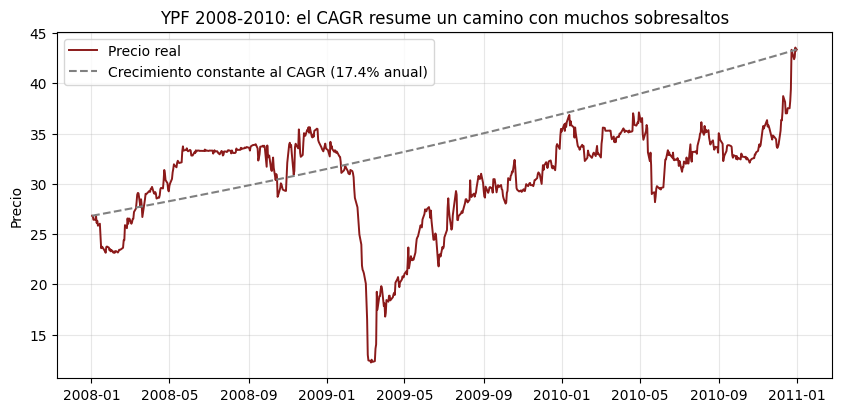

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(ypf["date"], ypf["price"], color="#8B1A1A", lw=1.4, label="Precio real")

# La "línea del CAGR": cómo habría crecido el precio a una tasa anual constante
tasa = cagr(precio_compra, precio_venta, años)
t = (ypf["date"] - ypf["date"].iloc[0]).dt.days / 365
ax.plot(ypf["date"], precio_compra * (1 + tasa) ** t, "--", color="gray",
        label=f"Crecimiento constante al CAGR ({tasa:.1%} anual)")

ax.set_title("YPF 2008-2010: el CAGR resume un camino con muchos sobresaltos")
ax.set_ylabel("Precio")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

> 💡 **Ojo con lo que el CAGR esconde:** la línea punteada sube tranquila, pero el precio real se
> desplomó a fines de 2008 (crisis financiera). El CAGR dice *cuánto* rindió en promedio, **no
> cuánto riesgo** se corrió en el camino.
>
> 💵 **Y otra cosa:** usamos solo el **precio**. No sumamos los **dividendos** que YPF pagó en esos
> años, así que este CAGR **subestima** lo que ganó realmente el accionista.

---
# 3️⃣ Payback — ¿En cuánto tiempo recupero la plata?

A partir de acá usamos **un solo caso** para todo el resto de la clase.

### 🥖 El caso: el horno nuevo de la panadería

Una panadería evalúa comprar un horno industrial. Cuesta **\$10.000.000** y le permite producir
más, con estos flujos de caja (en millones de pesos):

| Año | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| Flujo | −10 | 3 | 3,5 | 4 | 4 | 3 |

El costo de capital de los dueños (lo que ganarían en su mejor alternativa) es **20% anual**.

Primero, su ROI:

$$
ROI = \frac{(3 + 3{,}5 + 4 + 4 + 3) - 10}{10} = \frac{17{,}5 - 10}{10} = 75\%
$$

¡75%! Parece un negocio bárbaro. Veamos qué dicen las otras métricas.

In [8]:
horno = pd.DataFrame({
    "Año":   [0, 1, 2, 3, 4, 5],
    "Flujo": [-10_000_000, 3_000_000, 3_500_000, 4_000_000, 4_000_000, 3_000_000],
})
r = 0.20  # costo de capital

inversion_horno = -horno.loc[0, "Flujo"]
cobros_horno    = horno.loc[1:, "Flujo"].sum()
print(f"ROI del horno: {roi(cobros_horno, inversion_horno):.2%}")

ROI del horno: 75.00%


### Payback simple (PRS)

Sumamos los flujos **año por año** hasta cubrir la inversión:

| Año | Flujo | Acumulado |
|---|---|---|
| 0 | −10 | −10 |
| 1 | 3 | −7 |
| 2 | 3,5 | −3,5 |
| 3 | 4 | **+0,5** ← acá se recupera |

Al final del año 2 faltaban **3,5**; el año 3 trae **4**. Si el flujo llega parejo durante el año:

$$
PRS = 2 + \frac{3{,}5}{4} = 2 + 0{,}875 = 2{,}875 \text{ años} \approx 2 \text{ años y } 10{,}5 \text{ meses}
$$

In [9]:
def payback(flujos):
    # flujos: lista con el flujo de cada año; el primero es la inversión (negativo).
    # Devuelve los años hasta recuperar la inversión (interpolando dentro del año),
    # o None si nunca se recupera.
    acumulado = flujos[0]
    for año in range(1, len(flujos)):
        if acumulado + flujos[año] >= 0:
            faltante = -acumulado
            return (año - 1) + faltante / flujos[año]
        acumulado += flujos[año]
    return None

horno["Acumulado"] = horno["Flujo"].cumsum()
print(f"Payback simple: {payback(horno['Flujo'].tolist()):.3f} años")
horno

Payback simple: 2.875 años


,Año,Flujo,Acumulado
0,0,-10000000,-10000000
1,1,3000000,-7000000
2,2,3500000,-3500000
3,3,4000000,500000
4,4,4000000,4500000
5,5,3000000,7500000


### Payback descontado (PRD)

El simple tiene el mismo problema que el ROI: **trata igual un peso de hoy que uno de dentro de 5
años**. El descontado primero lleva cada flujo a valor presente (lo de la clase 13) y recién
después acumula:

$$
VP_t = \frac{F_t}{(1 + r)^t}
$$

| Año | Flujo | Factor $1{,}2^t$ | VP | VP acumulado |
|---|---|---|---|---|
| 0 | −10 | 1 | −10 | −10 |
| 1 | 3 | 1,2 | 2,500 | −7,500 |
| 2 | 3,5 | 1,44 | 2,431 | −5,069 |
| 3 | 4 | 1,728 | 2,315 | −2,755 |
| 4 | 4 | 2,0736 | 1,929 | −0,826 |
| 5 | 3 | 2,48832 | 1,206 | **+0,380** |

$$
PRD = 4 + \frac{0{,}826}{1{,}206} \approx 4{,}68 \text{ años}
$$

De **2,9 años** pasamos a **4,7 años**: el horno se paga recién en su último año de vida.

In [10]:
horno["VP"] = horno["Flujo"] / (1 + r) ** horno["Año"]
horno["VP acumulado"] = horno["VP"].cumsum()

prs = payback(horno["Flujo"].tolist())
prd = payback(horno["VP"].tolist())   # misma función, pero con los flujos ya descontados
print(f"Payback simple:     {prs:.2f} años")
print(f"Payback descontado: {prd:.2f} años")
horno.round(0)

Payback simple:     2.88 años
Payback descontado: 4.68 años


,Año,Flujo,Acumulado,VP,VP acumulado
0,0,-10000000,-10000000,-10000000.0,-10000000.0
1,1,3000000,-7000000,2500000.0,-7500000.0
2,2,3500000,-3500000,2430556.0,-5069444.0
3,3,4000000,500000,2314815.0,-2754630.0
4,4,4000000,4500000,1929012.0,-825617.0
5,5,3000000,7500000,1205633.0,380015.0


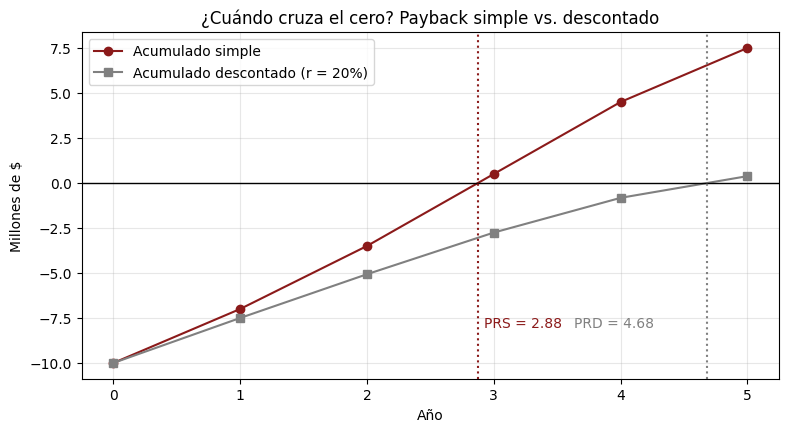

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(horno["Año"], horno["Acumulado"] / 1e6, "o-", color="#8B1A1A", label="Acumulado simple")
ax.plot(horno["Año"], horno["VP acumulado"] / 1e6, "s-", color="gray", label="Acumulado descontado (r = 20%)")
ax.axhline(0, color="black", lw=1)
ax.axvline(prs, ls=":", color="#8B1A1A")
ax.axvline(prd, ls=":", color="gray")
ax.text(prs + 0.05, -8, f"PRS = {prs:.2f}", color="#8B1A1A")
ax.text(prd - 1.05, -8, f"PRD = {prd:.2f}", color="gray")
ax.set_xlabel("Año")
ax.set_ylabel("Millones de $")
ax.set_title("¿Cuándo cruza el cero? Payback simple vs. descontado")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.show()

---
# 4️⃣ IR — Índice de rentabilidad

El **IR** es "un ROI que sí descuenta": divide el valor presente de lo que recibo por lo que puse.

$$
IR = \frac{\displaystyle\sum_{t=1}^{n} \frac{F_t}{(1+r)^t}}{I_0}
$$

- **IR > 1** → cada peso invertido genera más de un peso de valor *de hoy* → conviene.
- **IR < 1** → no conviene.

🔗 Relación con el VAN de la clase 13: como $VAN = VP_{\text{flujos}} - I_0$, se cumple
$IR = 1 + \dfrac{VAN}{I_0}$. Por eso **IR > 1 es lo mismo que VAN > 0**.

**Horno, a mano** (con la tabla de arriba):

$$
IR = \frac{2{,}500 + 2{,}431 + 2{,}315 + 1{,}929 + 1{,}206}{10} = \frac{10{,}380}{10} = 1{,}038
$$

In [12]:
vp_cobros = horno.loc[1:, "VP"].sum()
ir  = vp_cobros / inversion_horno
van = vp_cobros - inversion_horno

print(f"VP de los cobros: {vp_cobros:,.0f}")
print(f"VAN:              {van:,.0f}")
print(f"IR:               {ir:.3f}")

VP de los cobros: 10,380,015
VAN:              380,015
IR:               1.038


### 🧠 ¿Qué nos dijo cada métrica sobre el horno?

| Métrica | Valor | Lectura |
|---|---|---|
| ROI | 75% | "¡Negocio bárbaro!" |
| Payback simple | 2,9 años | "Se paga rápido" |
| Payback descontado | 4,7 años | "Se paga en el último año" |
| IR | 1,04 | "Por cada peso, genera 1,04 de hoy: apenas" |

**Conviene, pero por muy poco.** El ROI y el payback simple **inflaban** el proyecto porque
ignoraban que la plata de los dueños tiene un costo del 20% anual. Si los flujos vienen un poco
peor de lo esperado, el horno deja de convenir.

---
# 5️⃣ ROA y ROE — Evaluar la empresa en la que invierto

Hasta ahora evaluamos **un proyecto**. Pero muchas veces invertir es **comprar una parte de una
empresa**: acciones en la bolsa, o entrar como socio. Antes de hacerlo, los inversores miran qué
tan rentable es esa empresa con dos métricas que salen del balance:

$$
ROA = \frac{\text{Resultado operativo}}{\text{Activo total}}
\qquad\qquad
ROE = \frac{\text{Resultado neto}}{\text{Patrimonio neto}}
$$

- **ROA** (*Return on Assets*): cuánto rinde **todo lo que la empresa tiene**, sin importar quién
  lo financió.
- **ROE** (*Return on Equity*): cuánto rinde **la plata de los dueños**.

La diferencia entre los dos es **la deuda**: el resultado neto es el operativo menos los intereses,
y el patrimonio es el activo menos lo que se debe.

🔗 Con Rita vieron el WACC: la empresa se financia con deuda y con capital propio. Acá vemos qué
le pasa a la rentabilidad de los dueños según cuánto se endeude. Y si el **ROE supera lo que
exigen los dueños** (el costo del capital propio de la clase 13), la empresa está creando valor.

> ⚠️ **No reemplazan al VAN.** ROA y ROE usan datos **contables del pasado** (lo que dice el
> balance), no flujos de caja futuros. Sirven para **diagnosticar una empresa**, no para decidir si
> conviene un proyecto puntual.

### 🥖 La panadería, en tres versiones

Supongamos que nos ofrecen **entrar como socios** de la panadería. La panadería tiene **\$100 millones** de activos y gana **\$20 millones** de resultado operativo por
año → **ROA = 20%**. Para simplificar, ignoramos impuestos.

| | Sin deuda | Deuda barata | Deuda cara |
|---|---|---|---|
| Activo | 100 | 100 | 100 |
| Deuda | 0 | 60 al **10%** | 60 al **30%** |
| Patrimonio | 100 | 40 | 40 |
| Resultado operativo | 20 | 20 | 20 |
| Intereses | 0 | 6 | 18 |
| Resultado neto | 20 | 14 | 2 |
| **ROA** | 20% | 20% | 20% |
| **ROE** | **20%** | **35%** | **5%** |

A mano, para la deuda barata:

$$
ROE = \frac{20 - 0{,}10 \times 60}{100 - 60} = \frac{20 - 6}{40} = \frac{14}{40} = 35\%
$$

> 🎯 **El efecto palanca:** endeudarse **amplifica** la rentabilidad de los dueños si la deuda
> cuesta menos que lo que rinde el activo (10% < 20%), y la **destruye** si cuesta más (30% > 20%).
> El negocio es el mismo en las tres columnas; lo único que cambia es cómo se financia.

In [13]:
def roa(resultado_operativo, activo):
    return resultado_operativo / activo

def roe(resultado_operativo, activo, deuda, tasa_deuda):
    resultado_neto = resultado_operativo - tasa_deuda * deuda
    patrimonio     = activo - deuda
    return resultado_neto / patrimonio

ACTIVO, RES_OPERATIVO = 100, 20   # millones de pesos

escenarios = pd.DataFrame({
    "Escenario":  ["Sin deuda", "Deuda barata", "Deuda cara"],
    "Deuda":      [0, 60, 60],
    "Tasa deuda": [0.00, 0.10, 0.30],
})
escenarios["ROA"] = roa(RES_OPERATIVO, ACTIVO)
escenarios["ROE"] = roe(RES_OPERATIVO, ACTIVO, escenarios["Deuda"], escenarios["Tasa deuda"])
escenarios.style.format({"Tasa deuda": "{:.0%}", "ROA": "{:.0%}", "ROE": "{:.0%}"})

,Escenario,Deuda,Tasa deuda,ROA,ROE
0,Sin deuda,0,0%,20%,20%
1,Deuda barata,60,10%,20%,35%
2,Deuda cara,60,30%,20%,5%


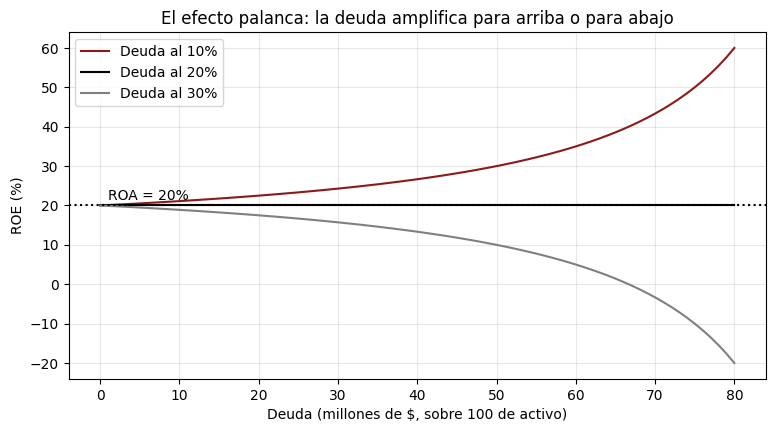

In [14]:
# ¿Cómo cambia el ROE a medida que me endeudo más? Una curva por cada tasa de interés
deudas = np.arange(0, 81, 1)

fig, ax = plt.subplots(figsize=(9, 4.5))
for tasa, color in [(0.10, "#8B1A1A"), (0.20, "black"), (0.30, "gray")]:
    ax.plot(deudas, roe(RES_OPERATIVO, ACTIVO, deudas, tasa) * 100, color=color,
            label=f"Deuda al {tasa:.0%}")
ax.axhline(roa(RES_OPERATIVO, ACTIVO) * 100, ls=":", color="black")
ax.text(1, 21.5, "ROA = 20%")
ax.set_xlabel("Deuda (millones de $, sobre 100 de activo)")
ax.set_ylabel("ROE (%)")
ax.set_title("El efecto palanca: la deuda amplifica para arriba o para abajo")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

> 💡 Fijate la curva negra: si la deuda cuesta **exactamente** lo mismo que rinde el activo (20%),
> el ROE no se mueve. Ese es el punto de quiebre del efecto palanca.

---
### 🌎 ROA y ROE con datos reales: Microsoft, Coca-Cola y Apple

La panadería era inventada. Ahora hacemos **exactamente las mismas cuentas** con empresas reales,
usando `yfinance` (la librería que usamos con YPF y NVDA).

Toda empresa que cotiza en bolsa publica dos estados contables que nos importan:

| Estado contable | Qué muestra | Lo que sacamos de ahí |
|---|---|---|
| **Estado de resultados** | Lo que **ganó** en el año | Ingresos, resultado operativo, EBITDA, resultado neto |
| **Balance** | Lo que **tiene** y lo que **debe** en una fecha | Activo, pasivo, patrimonio |

Vamos de a un paso, primero con Microsoft.

In [15]:
import yfinance as yf

msft = yf.Ticker("MSFT")

# Estado de resultados ANUAL: cada columna es un año, cada fila una partida
resultados = msft.financials

# Nos quedamos con las 4 filas que nos interesan y pasamos a millones de dólares
filas_resultados = ["Total Revenue", "Operating Income", "EBITDA", "Net Income"]
(resultados.loc[filas_resultados] / 1e6).round(0)

,2026-06-30,2025-06-30,2024-06-30,2023-06-30
Total Revenue,331839.0,281724.0,245122.0,211915.0
Operating Income,155237.0,128528.0,109433.0,88523.0
EBITDA,207519.0,155445.0,131680.0,105140.0
Net Income,133749.0,101832.0,88136.0,72361.0


**Cómo leer esta tabla** (cada columna es el cierre de un ejercicio; Microsoft cierra en junio):

- **Total Revenue** — ingresos: todo lo que vendió.
- **Operating Income** — resultado operativo: lo que gana **el negocio**, antes de intereses e impuestos.
  Es el "20" de la panadería.
- **EBITDA** — el resultado operativo **sumándole las amortizaciones** (el desgaste de equipos,
  edificios, licencias), que no son salida de plata en el año. Mide cuánta caja genera la operación.
- **Net Income** — resultado neto: lo que queda **para los dueños** después de intereses e impuestos.

In [16]:
# Balance ANUAL: lo que la empresa tiene (activo), lo que debe (pasivo) y lo que es de los dueños (patrimonio)
balance = msft.balance_sheet

filas_balance = ["Total Assets", "Total Liabilities Net Minority Interest", "Stockholders Equity"]
(balance.loc[filas_balance] / 1e6).round(0)

,2026-06-30,2025-06-30,2024-06-30,2023-06-30,2022-06-30
Total Assets,758376.0,619003.0,512163.0,411976.0,NaN
Total Liabilities Net Minority Interest,315989.0,275524.0,243686.0,205753.0,NaN
Stockholders Equity,442387.0,343479.0,268477.0,206223.0,NaN


- **Total Assets** — activo: todo lo que tiene (el "100" de la panadería).
- **Total Liabilities** — pasivo: todo lo que debe (deudas, proveedores, etc.).
- **Stockholders Equity** — patrimonio: lo que es **de los dueños**.

Se tiene que cumplir siempre la **ecuación contable**: $\text{Activo} = \text{Pasivo} + \text{Patrimonio}$.
Chequeémoslo (puede haber una diferencia chica por las participaciones minoritarias):

In [17]:
activo     = balance.loc["Total Assets"].iloc[0]          # .iloc[0] = el año más reciente
pasivo     = balance.loc["Total Liabilities Net Minority Interest"].iloc[0]
patrimonio = balance.loc["Stockholders Equity"].iloc[0]

print(f"Activo:               {activo / 1e6:>12,.0f} millones")
print(f"Pasivo + patrimonio:  {(pasivo + patrimonio) / 1e6:>12,.0f} millones")

Activo:                    758,376 millones
Pasivo + patrimonio:       758,376 millones


#### Las cuentas, una por una

Son las mismas fórmulas de la panadería. Usamos el **resultado neto** en las dos, que es como
se publican en el mercado (en la panadería usamos el operativo para el ROA, para ver limpio el efecto
de la deuda):

$$
ROE = \frac{\text{Resultado neto}}{\text{Patrimonio}}
\qquad
ROA = \frac{\text{Resultado neto}}{\text{Activo}}
\qquad
\text{Margen EBITDA} = \frac{\text{EBITDA}}{\text{Ingresos}}
\qquad
\text{Apalancamiento} = \frac{\text{Activo}}{\text{Patrimonio}}
$$

In [18]:
ingresos = resultados.loc["Total Revenue"].iloc[0]
ebitda   = resultados.loc["EBITDA"].iloc[0]
neto     = resultados.loc["Net Income"].iloc[0]

roe_msft = neto / patrimonio
roa_msft = neto / activo

print(f"ROE:            {roe_msft:.1%}   -> por cada dólar de los dueños, ganó {roe_msft * 100:.0f} centavos")
print(f"ROA:            {roa_msft:.1%}   -> por cada dólar de activo, ganó {roa_msft * 100:.0f} centavos")
print(f"Margen EBITDA:  {ebitda / ingresos:.1%}   -> de cada dólar que vende, {ebitda / ingresos * 100:.0f} centavos de caja operativa")
print(f"Apalancamiento: {activo / patrimonio:.2f}x  -> por cada dólar de los dueños, tiene {activo / patrimonio:.2f} de activo")

ROE:            30.2%   -> por cada dólar de los dueños, ganó 30 centavos
ROA:            17.6%   -> por cada dólar de activo, ganó 18 centavos
Margen EBITDA:  62.5%   -> de cada dólar que vende, 63 centavos de caja operativa
Apalancamiento: 1.71x  -> por cada dólar de los dueños, tiene 1.71 de activo


#### Ahora las tres empresas

Para no repetir el código tres veces, metemos los pasos de arriba **en una función** y la llamamos
con cada ticker.

In [19]:
def metricas(ticker):
    # Los mismos pasos de arriba, para cualquier empresa
    empresa    = yf.Ticker(ticker)
    resultados = empresa.financials
    balance    = empresa.balance_sheet

    neto       = resultados.loc["Net Income"].iloc[0]
    ingresos   = resultados.loc["Total Revenue"].iloc[0]
    ebitda     = resultados.loc["EBITDA"].iloc[0]
    activo     = balance.loc["Total Assets"].iloc[0]
    patrimonio = balance.loc["Stockholders Equity"].iloc[0]

    return {
        "Empresa":        ticker,
        "Ejercicio":      resultados.columns[0].year,
        "ROE":            neto / patrimonio,
        "ROA":            neto / activo,
        "Margen EBITDA":  ebitda / ingresos,
        "Apalancamiento": activo / patrimonio,
    }

comparacion = pd.DataFrame([metricas(t) for t in ["MSFT", "KO", "AAPL"]])
comparacion.style.format({"ROE": "{:.1%}", "ROA": "{:.1%}", "Margen EBITDA": "{:.1%}",
                          "Apalancamiento": "{:.2f}x"})

,Empresa,Ejercicio,ROE,ROA,Margen EBITDA,Apalancamiento
0,MSFT,2026,30.2%,17.6%,62.5%,1.71x
1,KO,2025,40.7%,12.5%,39.0%,3.26x
2,AAPL,2025,151.9%,31.2%,34.8%,4.87x


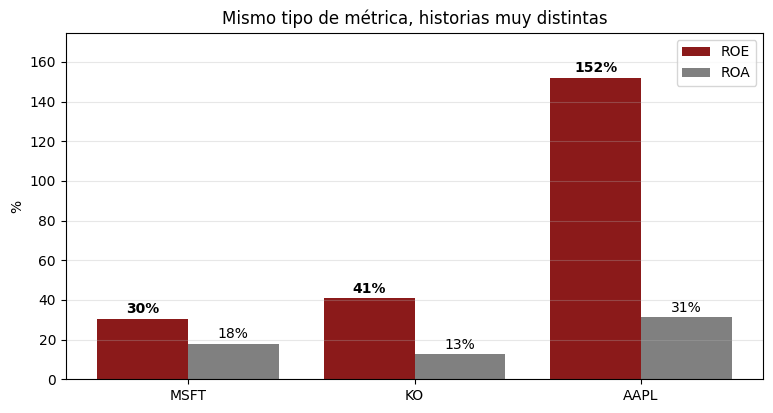

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparacion))
ax.bar(x - 0.2, comparacion["ROE"] * 100, width=0.4, color="#8B1A1A", label="ROE")
ax.bar(x + 0.2, comparacion["ROA"] * 100, width=0.4, color="gray", label="ROA")
for i, fila in comparacion.iterrows():
    ax.text(i - 0.2, fila["ROE"] * 100 + 3, f"{fila['ROE']:.0%}", ha="center", fontweight="bold")
    ax.text(i + 0.2, fila["ROA"] * 100 + 3, f"{fila['ROA']:.0%}", ha="center")
ax.set_xticks(x, comparacion["Empresa"])
ax.set_ylim(0, comparacion["ROE"].max() * 100 * 1.15)
ax.set_ylabel("%")
ax.set_title("Mismo tipo de métrica, historias muy distintas")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

### 🧠 ¿Qué nos dicen? Las tres historias del ROE alto

| Empresa | Qué pasa | El caso de la panadería que se le parece |
|---|---|---|
| **Microsoft** | ROE alto **y** ROA alto, con poca deuda (apalancamiento ~1,7x) | **Buen negocio**: el ROE es alto porque el negocio rinde, no por la deuda |
| **Coca-Cola** | ROE más alto que Microsoft, pero ROA **más bajo**; apalancamiento ~3,3x | **Efecto palanca**: la deuda agranda el ROE |
| **Apple** | ROE **enorme** (más de 100%) con un ROA excelente pero mucho menor | **Patrimonio chico**: Apple recompra muchas de sus propias acciones, el patrimonio se achica y el ROE se infla |

> 🎯 **¿Apple es cinco veces mejor negocio que Microsoft porque su ROE es cinco veces más alto? No.**
> El ROE solo no alcanza: hay que mirarlo **junto con el ROA y el apalancamiento** para saber de
> dónde sale.

> ⚠️ **Dos aclaraciones honestas:**
> - Los datos se bajan **en vivo**: si Microsoft, Coca-Cola o Apple publican un balance nuevo, los
>   números cambian.
> - Yahoo reprocesa los balances con **sus propias definiciones**. El ROE y el ROA coinciden con los
>   balances oficiales que las empresas presentan ante la SEC (el regulador de EE.UU.), pero el
>   **EBITDA de Yahoo suma más partidas** que el cálculo estándar (operativo + amortizaciones) y da
>   un poco más alto. Moraleja: **antes de comparar una métrica, fijate cómo está calculada.**

---
# 6️⃣ FTE — Medir el trabajo que libera un proyecto

Muchos proyectos de hoy (automatizar un proceso, sumar un sistema, incorporar IA) **no venden más:
ahorran tiempo**. Para meter ese ahorro en un ROI hay que traducir horas a plata, y la unidad
estándar para eso es el **FTE**.

**FTE** (*Full-Time Equivalent*) = equivalente a **una persona trabajando a tiempo completo**:

$$
FTE = \frac{\text{Horas de trabajo que requiere la tarea}}{\text{Horas que trabaja una persona en el período}}
$$

Si una tarea consume 320 horas por mes y una persona trabaja 160 horas mensuales, la tarea ocupa
**2 FTE**. No importa si son 2 personas full-time o 4 part-time: la carga es la misma.

### 🧾 El caso: automatizar la carga de facturas

La panadería carga a mano **3.000 facturas por mes**, a **6 minutos** cada una. Evalúa un sistema
que baja ese tiempo a **1 minuto** por factura.

$$
\begin{aligned}
\text{Horas antes}   &= \frac{3.000 \times 6}{60} = 300 \text{ h/mes} \\
\text{Horas después} &= \frac{3.000 \times 1}{60} = 50 \text{ h/mes} \\
\text{Horas liberadas} &= 250 \text{ h/mes} \\
FTE \text{ liberados} &= \frac{250}{160} = 1{,}5625
\end{aligned}
$$

In [21]:
HORAS_MES_PERSONA = 160

facturas_mes      = 3_000
minutos_antes     = 6
minutos_despues   = 1

horas_antes    = facturas_mes * minutos_antes / 60
horas_despues  = facturas_mes * minutos_despues / 60
horas_liberadas = horas_antes - horas_despues
fte_liberados   = horas_liberadas / HORAS_MES_PERSONA

print(f"Horas por mes antes:    {horas_antes:.0f}")
print(f"Horas por mes después:  {horas_despues:.0f}")
print(f"Horas liberadas por mes: {horas_liberadas:.0f}")
print(f"FTE liberados:           {fte_liberados:.4f}")

Horas por mes antes:    300
Horas por mes después:  50
Horas liberadas por mes: 250
FTE liberados:           1.5625


### ⚠️ Horas liberadas ≠ plata ahorrada

Una persona a tiempo completo le cuesta a la panadería **\$16.800.000 por año** (sueldo + cargas).
Si multiplicamos, los 1,56 FTE "valen" \$26,25 millones por año. Pero **ese ahorro solo existe si
la empresa hace algo con el tiempo liberado**:

| Escenario | Qué pasa con las horas | Ahorro que se captura |
|---|---|---|
| **Reasignar** | La gente pasa a tareas que generan valor (atender clientes, cobrar) | 100% |
| **Absorber parcialmente** | Se reduce algo de horas extra, el resto se diluye | 50% |
| **No capturar** | Nadie cambia nada: la gente "tiene más tiempo libre" | 0% |

El sistema cuesta **\$12.000.000** de implementación más **\$3.000.000** por año de licencia, y
estimamos que sirve **3 años**. Medimos dos cosas en cada escenario:

$$
\begin{aligned}
ROI_{3\text{ años}} &= \frac{3 \times \text{Ahorro anual capturado} - (12 + 3 \times 3)}{12 + 3 \times 3} \\[4pt]
\text{Payback (meses)} &= \frac{\text{Inversión inicial}}{\text{Ahorro mensual} - \text{Licencia mensual}}
\end{aligned}
$$

> 💡 **¿Por qué no el ROI del primer año?** Porque compararía el ahorro de **un** año contra una
> inversión que dura **tres**: castigaría de más al proyecto. El horizonte tiene que ser la vida útil.

In [22]:
COSTO_FTE_ANUAL   = 16_800_000
COSTO_INICIAL     = 12_000_000
LICENCIA_ANUAL    = 3_000_000
HORIZONTE         = 3            # años de vida útil del sistema

ahorro_potencial = fte_liberados * COSTO_FTE_ANUAL
costo_total      = COSTO_INICIAL + LICENCIA_ANUAL * HORIZONTE

def payback_meses(ahorro_anual):
    # Meses hasta recuperar la inversión inicial con el ahorro neto de licencia.
    # Si el ahorro no cubre ni la licencia, no se recupera nunca.
    ahorro_neto_mensual = (ahorro_anual - LICENCIA_ANUAL) / 12
    return COSTO_INICIAL / ahorro_neto_mensual if ahorro_neto_mensual > 0 else None

captura = pd.DataFrame({
    "Escenario": ["Reasignar", "Absorber parcialmente", "No capturar"],
    "% capturado": [1.0, 0.5, 0.0],
})
captura["Ahorro anual"]    = ahorro_potencial * captura["% capturado"]
captura["ROI 3 años"]      = roi(captura["Ahorro anual"] * HORIZONTE, costo_total)
captura["Payback (meses)"] = captura["Ahorro anual"].apply(payback_meses)

print(f"Ahorro potencial anual: {ahorro_potencial:,.0f}")
captura.style.format({"% capturado": "{:.0%}", "Ahorro anual": "{:,.0f}", "ROI 3 años": "{:.1%}",
                      "Payback (meses)": "{:.1f}"}, na_rep="nunca")

Ahorro potencial anual: 26,250,000


,Escenario,% capturado,Ahorro anual,ROI 3 años,Payback (meses)
0,Reasignar,100%,"26,250,000",275.0%,6.2
1,Absorber parcialmente,50%,"13,125,000",87.5%,14.2
2,No capturar,0%,0,-100.0%,nunca


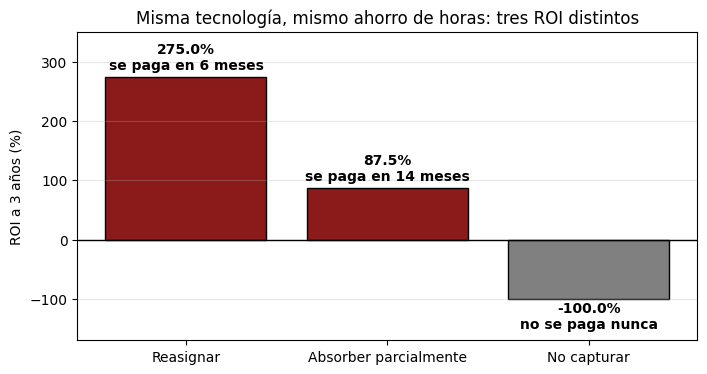

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#8B1A1A" if v >= 0 else "gray" for v in captura["ROI 3 años"]]
ax.bar(captura["Escenario"], captura["ROI 3 años"] * 100, color=colores, edgecolor="black")
ax.axhline(0, color="black", lw=1)
for i, (v, pb) in enumerate(zip(captura["ROI 3 años"] * 100, captura["Payback (meses)"])):
    texto = f"{v:.1f}%\n" + ("no se paga nunca" if pd.isna(pb) else f"se paga en {pb:.0f} meses")
    ax.text(i, v + 12 if v >= 0 else v - 50, texto, ha="center", fontweight="bold")
ax.set_ylim(-170, 350)
ax.set_ylabel("ROI a 3 años (%)")
ax.set_title("Misma tecnología, mismo ahorro de horas: tres ROI distintos")
ax.grid(axis="y", alpha=0.3)
plt.show()

> 🚨 **La lección:** el sistema funciona igual en los tres escenarios (libera 1,56 FTE). Pero se
> paga en **6 meses**, en **14 meses** o **nunca**: lo que cambia es **la decisión de gestión**
> sobre qué hacer con ese tiempo. Antes de calcular el
> ROI de un proyecto de automatización, la primera pregunta es: **¿por qué canal exacto se
> convierten estas horas en plata?**

---
# 🧭 Resumen: qué pregunta responde cada métrica

| Métrica | Pregunta | Unidad | Umbral | ¿Mira el tiempo? |
|---|---|---|---|---|
| **ROI** | ¿Cuánto gané por peso invertido? | % | > 0 | ❌ |
| **CAGR** | ¿Cuánto rindió por año? | % anual | > r | ✅ (anualiza) |
| **Payback simple** | ¿Cuándo recupero la plata? | años | < máximo aceptado | ❌ |
| **Payback descontado** | ¿Cuándo la recupero, en valor de hoy? | años | < máximo aceptado | ✅ |
| **IR** | ¿Cuánto valor de hoy por peso invertido? | veces | > 1 | ✅ |
| **ROA** | ¿Cuánto rinde todo el activo? | % | > costo de la deuda | — |
| **ROE** | ¿Cuánto rinde la plata de los dueños? | % | > lo que exigen los dueños | — |
| **FTE** | ¿Cuánto trabajo libera (o consume)? | personas equivalentes | — | — |

Y de la clase 13: **VAN** (¿cuánta plata de hoy me deja?) y **TIR / TIRM** (¿a qué tasa empata?).

---
# 📝 Ejercicios

**Ejercicio 1 — ROI vs. CAGR.** Un inversor compró un departamento en \$40.000 (USD) y lo vendió
7 años después en \$58.000. Otro compró un auto clásico en \$40.000 y lo vendió a los 2 años en
\$50.000. Calculá el ROI y el CAGR de cada uno. ¿Cuál fue mejor inversión? ¿Coinciden las dos
métricas?

**Ejercicio 2 — Payback e IR.** Una imprenta evalúa una máquina de \$8.000.000 que genera flujos de
\$2.500.000 por año durante 5 años. Con un costo de capital del 25%: calculá el ROI, el payback
simple, el payback descontado y el IR. ¿Conviene?

**Ejercicio 3 — ROE.** Una empresa tiene \$50 millones de activo y un resultado operativo de \$9
millones. ¿Qué ROE obtienen los dueños si se financia con \$30 millones de deuda al 12%? ¿Y al 25%?
¿A partir de qué tasa de interés le conviene **no** endeudarse?

**Ejercicio 4 — FTE.** Un estudio contable responde 1.200 consultas por mes, a 15 minutos cada una.
Un asistente automático resuelve el 40% de las consultas sin intervención humana. ¿Cuántos FTE
libera? Si el costo anual de un FTE es \$18.000.000, ¿cuál es el ahorro potencial? ¿Y el capturado
si solo se reasigna la mitad de las horas?

In [24]:
# Ejercicio 1 - tu código acá

In [25]:
# Ejercicio 2 - tu código acá

In [26]:
# Ejercicio 3 - tu código acá

In [27]:
# Ejercicio 4 - tu código acá

---
## ✅ Soluciones

Intentá resolverlos antes de mirar. 😉

In [28]:
# Solución ejercicio 1
for nombre, compra, venta, años_tenencia in [("Departamento", 40_000, 58_000, 7),
                                             ("Auto clásico", 40_000, 50_000, 2)]:
    print(f"{nombre:13s} ROI = {roi(venta, compra):6.2%}   CAGR = {cagr(compra, venta, años_tenencia):6.2%}")
# El departamento tiene mayor ROI (45% vs 25%), pero el auto rindió más POR AÑO (11,8% vs 5,5%).

Departamento  ROI = 45.00%   CAGR =  5.45%
Auto clásico  ROI = 25.00%   CAGR = 11.80%


In [29]:
# Solución ejercicio 2
flujos = [-8_000_000] + [2_500_000] * 5
tasa = 0.25
vp = [f / (1 + tasa) ** t for t, f in enumerate(flujos)]

print(f"ROI:                {roi(sum(flujos[1:]), -flujos[0]):.2%}")
print(f"Payback simple:     {payback(flujos):.2f} años")
prd_ej = payback(vp)
print(f"Payback descontado: {'no se recupera' if prd_ej is None else f'{prd_ej:.2f} años'}")
print(f"IR:                 {sum(vp[1:]) / -flujos[0]:.3f}")
# ROI de 56% y payback de 3,2 años... pero IR < 1: con un costo de capital del 25% NO conviene.

ROI:                56.25%
Payback simple:     3.20 años
Payback descontado: no se recupera
IR:                 0.840


In [30]:
# Solución ejercicio 3
for tasa_deuda in [0.12, 0.25]:
    print(f"Deuda al {tasa_deuda:.0%}: ROE = {roe(9, 50, 30, tasa_deuda):.1%}")
print(f"ROA = {roa(9, 50):.0%} -> con deuda más cara que el 18% conviene no endeudarse")

Deuda al 12%: ROE = 27.0%
Deuda al 25%: ROE = 7.5%
ROA = 18% -> con deuda más cara que el 18% conviene no endeudarse


In [31]:
# Solución ejercicio 4
horas_liberadas_ej = 1_200 * 0.40 * 15 / 60
fte_ej = horas_liberadas_ej / HORAS_MES_PERSONA
ahorro_pot = fte_ej * 18_000_000
print(f"Horas liberadas por mes: {horas_liberadas_ej:.0f}")
print(f"FTE liberados:           {fte_ej:.3f}")
print(f"Ahorro potencial anual:  {ahorro_pot:,.0f}")
print(f"Ahorro capturado (50%):  {ahorro_pot * 0.5:,.0f}")

Horas liberadas por mes: 120
FTE liberados:           0.750
Ahorro potencial anual:  13,500,000
Ahorro capturado (50%):  6,750,000
